# PdM ML Notebook

`viz_sample_data.csv`를 기반으로 수요예측과 이상탐지를 수행합니다.

## 1. 환경 설정 및 데이터 로드

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.unicode_minus"] = False

In [2]:
base_dir = Path.cwd()
sample_file = base_dir / "viz_sample_data.csv"
output_dir = base_dir / "ml_outputs"
output_dir.mkdir(exist_ok=True)

if not sample_file.exists():
    raise FileNotFoundError(
        f"{sample_file} 파일이 없습니다. Untitled-1.ipynb에서 viz_sample_data.csv를 먼저 생성해주세요."
    )

df = pd.read_csv(sample_file)
print("sample file:", sample_file)
print("shape:", df.shape)
display(df.head())

sample file: c:\Users\EL094\Documents\PdM_Project\viz_sample_data.csv
shape: (200000, 19)


,module(equipment),timestamp,localtime,operation,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,accumActiveEnergy
0,11(우측분전반1),2025-02-10 15:28:45,2025-02-10 07:28:45,1,219.94,216.32,215.10,377.80,373.61,376.74,27.56,8.29,29.79,3803.60,88.72,87.59,91.39,671.12,6279811
1,16(호이스트),2025-01-03 02:14:10,2025-01-02 18:14:10,1,219.49,215.70,215.90,376.87,373.76,377.04,17.61,15.70,21.36,3162.92,95.02,87.20,95.72,648.98,3558791
2,1(PM-3),2024-12-08 12:05:20,2024-12-08 04:05:20,1,218.88,211.26,211.23,372.50,365.87,372.48,27.19,28.72,21.91,4439.34,95.55,92.01,93.57,914.30,2473761
3,17(6호기),2025-03-26 21:44:10,2025-03-26 14:44:10,1,216.92,217.67,216.62,376.36,376.10,375.45,28.14,29.51,11.46,4002.38,99.60,96.53,92.42,1156.05,10227515
4,4(분쇄기(1)),2025-01-28 04:08:05,2025-01-27 20:08:05,1,211.72,219.23,215.82,373.20,376.76,370.25,17.74,19.72,8.96,2670.23,92.02,96.45,91.58,449.17,6639345


In [3]:
for col in ["timestamp", "localtime"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

module_col = "module(equipment)"
time_col = "timestamp"

numeric_cols = [
    "voltageR", "voltageS", "voltageT",
    "voltageRS", "voltageST", "voltageTR",
    "currentR", "currentS", "currentT",
    "activePower", "powerFactorR", "powerFactorS", "powerFactorT",
    "reactivePowerLagging", "accumActiveEnergy"
]
numeric_cols = [c for c in numeric_cols if c in df.columns]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=[module_col, time_col]).sort_values([module_col, time_col]).reset_index(drop=True)

if "activePower" not in df.columns:
    raise ValueError("activePower 컬럼이 필요합니다.")

if "energy_kwh_5s" not in df.columns:
    df["energy_kwh_5s"] = df["activePower"] * (5 / 3600) / 1000

print(df.dtypes)
display(df[[module_col, time_col, "activePower", "energy_kwh_5s"]].head())

module(equipment)                  str
timestamp               datetime64[us]
localtime               datetime64[us]
operation                        int64
voltageR                       float64
voltageS                       float64
voltageT                       float64
voltageRS                      float64
voltageST                      float64
voltageTR                      float64
currentR                       float64
currentS                       float64
currentT                       float64
activePower                    float64
powerFactorR                   float64
powerFactorS                   float64
powerFactorT                   float64
reactivePowerLagging           float64
accumActiveEnergy                int64
energy_kwh_5s                  float64
dtype: object


,module(equipment),timestamp,activePower,energy_kwh_5s
0,1(PM-3),2024-12-01 08:29:20,1940.61,0.002695
1,1(PM-3),2024-12-01 09:20:15,3062.40,0.004253
2,1(PM-3),2024-12-01 09:34:30,2351.44,0.003266
3,1(PM-3),2024-12-01 09:38:20,3983.06,0.005532
4,1(PM-3),2024-12-01 09:50:10,3098.20,0.004303


## 2. 수요예측용 데이터셋 생성

In [11]:
def add_calendar_features(frame, dt_col):
    out = frame.copy()
    out["year"] = out[dt_col].dt.year
    out["month"] = out[dt_col].dt.month
    out["day"] = out[dt_col].dt.day
    out["dayofweek"] = out[dt_col].dt.dayofweek
    out["hour"] = out[dt_col].dt.hour
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)
    return out

agg_map = {
    "energy_kwh_5s": "sum",
    "activePower": ["mean", "max"]
}
if "currentR" in df.columns:
    agg_map["currentR"] = "mean"
if "voltageR" in df.columns:
    agg_map["voltageR"] = "mean"

hourly_bucket = df[time_col].dt.normalize() + pd.to_timedelta(df[time_col].dt.hour, unit="h")
daily_bucket = df[time_col].dt.normalize()

hourly_df = df.assign(bucket=hourly_bucket).groupby([module_col, "bucket"]).agg(agg_map)
hourly_df.columns = ["_".join([c for c in col if c]).rstrip("_") for col in hourly_df.columns.to_flat_index()]
hourly_df = hourly_df.reset_index().rename(columns={
    "bucket": "ds",
    "energy_kwh_5s_sum": "energy_kwh",
    "activePower_mean": "activePower_mean",
    "activePower_max": "activePower_max",
    "currentR_mean": "currentR_mean",
    "voltageR_mean": "voltageR_mean"
})
hourly_df = add_calendar_features(hourly_df, "ds")

daily_df = df.assign(bucket=daily_bucket).groupby([module_col, "bucket"]).agg(agg_map)
daily_df.columns = ["_".join([c for c in col if c]).rstrip("_") for col in daily_df.columns.to_flat_index()]
daily_df = daily_df.reset_index().rename(columns={
    "bucket": "ds",
    "energy_kwh_5s_sum": "energy_kwh",
    "activePower_mean": "activePower_mean",
    "activePower_max": "activePower_max",
    "currentR_mean": "currentR_mean",
    "voltageR_mean": "voltageR_mean"
})
daily_df = add_calendar_features(daily_df, "ds")

print("hourly_df:", hourly_df.shape)
print("daily_df:", daily_df.shape)
display(hourly_df.head())
display(daily_df.head())


hourly_df: (46122, 13)
daily_df: (1963, 13)


,module(equipment),ds,energy_kwh,activePower_mean,activePower_max,currentR_mean,voltageR_mean,year,month,day,dayofweek,hour,is_weekend
0,1(PM-3),2024-12-01 08:00:00,0.002695,1940.610000,1940.61,8.490000,212.080000,2024,12,1,6,8,1
1,1(PM-3),2024-12-01 09:00:00,0.021135,3043.440000,3983.06,10.106000,213.090000,2024,12,1,6,9,1
2,1(PM-3),2024-12-01 10:00:00,0.030608,3148.264286,4757.37,18.517143,215.281429,2024,12,1,6,10,1
3,1(PM-3),2024-12-01 11:00:00,0.018628,2682.438000,3775.46,18.664000,217.430000,2024,12,1,6,11,1
4,1(PM-3),2024-12-01 12:00:00,0.017138,3084.787500,3459.48,16.730000,211.842500,2024,12,1,6,12,1


,module(equipment),ds,energy_kwh,activePower_mean,activePower_max,currentR_mean,voltageR_mean,year,month,day,dayofweek,hour,is_weekend
0,1(PM-3),2024-12-01,0.248742,2984.909167,4757.37,16.360000,214.131833,2024,12,1,6,0,1
1,1(PM-3),2024-12-02,0.397459,2980.942396,4649.35,17.261771,214.935417,2024,12,2,0,0,0
2,1(PM-3),2024-12-03,0.350595,2901.476667,4552.13,15.734713,215.345862,2024,12,3,1,0,0
3,1(PM-3),2024-12-04,0.503247,3070.657966,4799.92,17.219068,214.863136,2024,12,4,2,0,0
4,1(PM-3),2024-12-05,0.428017,2934.977048,4757.74,17.650286,214.813048,2024,12,5,3,0,0


In [12]:
def add_lag_features(frame, group_col, target_col, lag_steps, rolling_windows):
    out = frame.copy()
    for lag in lag_steps:
        out[f"lag_{lag}"] = out.groupby(group_col)[target_col].shift(lag)
    for window in rolling_windows:
        out[f"roll_mean_{window}"] = (
            out.groupby(group_col)[target_col]
               .shift(1)
               .rolling(window=window, min_periods=window)
               .mean()
        )
    return out

hourly_model_df = add_lag_features(hourly_df, module_col, "energy_kwh", [1, 2, 3, 6, 12, 24, 48, 168], [3, 6, 24]).dropna().reset_index(drop=True)
daily_model_df = add_lag_features(daily_df, module_col, "energy_kwh", [1, 2, 3, 7, 14, 21], [3, 7, 14]).dropna().reset_index(drop=True)

print("hourly_model_df:", hourly_model_df.shape)
print("daily_model_df:", daily_model_df.shape)

hourly_model_df: (43938, 24)
daily_model_df: (1690, 22)


## 3. 수요예측: 시간대별/일별 전력량 예측 모델

In [17]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-9, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE_pct": mape}



def train_forecast_model(frame, freq_name):
    work = frame.copy().sort_values("ds").reset_index(drop=True)
    work = pd.get_dummies(work, columns=[module_col], drop_first=False)
    feature_cols = [c for c in work.columns if c not in ["ds", "energy_kwh"]]

    split_idx = int(len(work) * 0.8)
    train_df = work.iloc[:split_idx].copy()
    test_df = work.iloc[split_idx:].copy()

    X_train = train_df[feature_cols]
    y_train = train_df["energy_kwh"]
    X_test = test_df[feature_cols]
    y_test = test_df["energy_kwh"]

    model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    metrics = regression_metrics(y_test, pred)
    metrics["dataset"] = freq_name
    metrics["train_rows"] = len(train_df)
    metrics["test_rows"] = len(test_df)

    pred_df = test_df[["ds"]].copy()
    pred_df["actual_energy_kwh"] = y_test.values
    pred_df["pred_energy_kwh"] = pred
    return model, pd.DataFrame([metrics]), pred_df

hourly_model, hourly_metrics, hourly_pred = train_forecast_model(hourly_model_df, "hourly")
daily_model, daily_metrics, daily_pred = train_forecast_model(daily_model_df, "daily")

forecast_metrics = pd.concat([hourly_metrics, daily_metrics], ignore_index=True)
display(forecast_metrics)

hourly_pred.to_csv(output_dir / "hourly_forecast_predictions.csv", index=False, encoding="utf-8-sig")
daily_pred.to_csv(output_dir / "daily_forecast_predictions.csv", index=False, encoding="utf-8-sig")

,MAE,RMSE,MAPE_pct,dataset,train_rows,test_rows
0,0.004818,0.006386,30.181869,hourly,35150,8788
1,0.044830,0.071658,17.322540,daily,1352,338


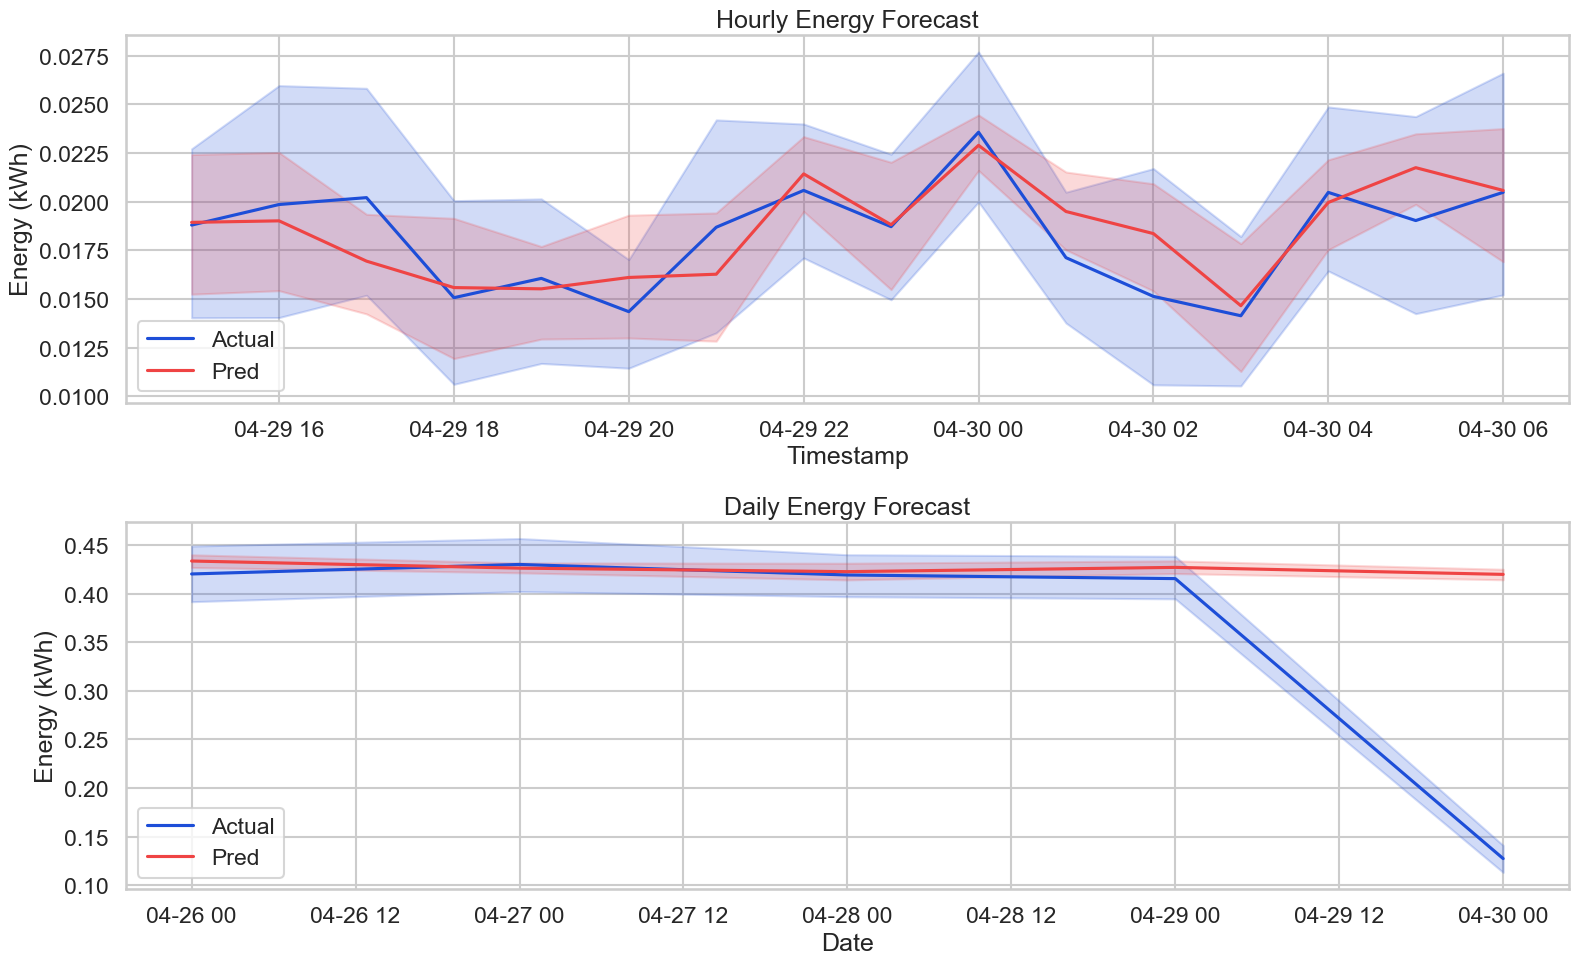

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

plot_hourly = hourly_pred.tail(200).copy()
plot_daily = daily_pred.tail(60).copy()

sns.lineplot(data=plot_hourly, x="ds", y="actual_energy_kwh", label="Actual", ax=axes[0], color="#1d4ed8")
sns.lineplot(data=plot_hourly, x="ds", y="pred_energy_kwh", label="Pred", ax=axes[0], color="#ef4444")
axes[0].set_title("Hourly Energy Forecast")
axes[0].set_xlabel("Timestamp")
axes[0].set_ylabel("Energy (kWh)")

sns.lineplot(data=plot_daily, x="ds", y="actual_energy_kwh", label="Actual", ax=axes[1], color="#1d4ed8")
sns.lineplot(data=plot_daily, x="ds", y="pred_energy_kwh", label="Pred", ax=axes[1], color="#ef4444")
axes[1].set_title("Daily Energy Forecast")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Energy (kWh)")

plt.tight_layout()
plt.show()

## 4. 이상탐지: Rule-Based + ML 기반 탐지

In [19]:
anomaly_feature_cols = [c for c in ["activePower", "currentR", "currentS", "currentT", "voltageR", "voltageS", "voltageT"] if c in df.columns]

rule_df = df[[module_col, time_col] + anomaly_feature_cols].copy()
rule_df["rule_anomaly"] = 0
rule_df["rule_reason"] = "normal"

for col in anomaly_feature_cols:
    q1 = rule_df.groupby(module_col)[col].transform(lambda s: s.quantile(0.25))
    q3 = rule_df.groupby(module_col)[col].transform(lambda s: s.quantile(0.75))
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    low_flag = rule_df[col] < lower
    high_flag = rule_df[col] > upper
    flag = low_flag | high_flag

    rule_df.loc[flag, "rule_anomaly"] = 1
    rule_df.loc[low_flag, "rule_reason"] = rule_df.loc[low_flag, "rule_reason"] + f"|{col}_low"
    rule_df.loc[high_flag, "rule_reason"] = rule_df.loc[high_flag, "rule_reason"] + f"|{col}_high"

rule_df["rule_reason"] = rule_df["rule_reason"].str.strip("|")
rule_summary = rule_df.groupby(module_col, as_index=False)["rule_anomaly"].sum().rename(columns={"rule_anomaly": "rule_anomaly_count"})
display(rule_summary.sort_values("rule_anomaly_count", ascending=False))

,module(equipment),rule_anomaly_count
3,13(3호기),87
8,18(우측분전반2),8
9,2(L-1전등),7
0,1(PM-3),6
12,5(좌측분전반),6
5,15(예비건조기),6
11,4(분쇄기(1)),5
4,14(2호기),5
7,17(6호기),4
10,3(분쇄기(2)),4


In [20]:
ml_feature_cols = [c for c in ["activePower", "currentR", "currentS", "currentT", "voltageR", "voltageS", "voltageT", "powerFactorR", "powerFactorS", "powerFactorT"] if c in df.columns]

ml_df = df[[module_col, time_col] + ml_feature_cols].dropna().copy()
ml_df["hour"] = ml_df[time_col].dt.hour
ml_df["dayofweek"] = ml_df[time_col].dt.dayofweek
module_lookup = ml_df[[time_col, module_col]].copy()
ml_df = pd.get_dummies(ml_df, columns=[module_col], drop_first=False)

feature_cols = [c for c in ml_df.columns if c != time_col]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(ml_df[feature_cols])

iso_model = IsolationForest(n_estimators=300, contamination=0.01, random_state=42, n_jobs=-1)
ml_df["iforest_pred"] = iso_model.fit_predict(X_scaled)
ml_df["iforest_anomaly"] = (ml_df["iforest_pred"] == -1).astype(int)
ml_df["iforest_score"] = iso_model.decision_function(X_scaled)

ml_result = ml_df.merge(module_lookup, on=time_col, how="left")
print("IsolationForest anomalies:", int(ml_result["iforest_anomaly"].sum()))

IsolationForest anomalies: 2153


In [21]:
rule_anomalies = rule_df[rule_df["rule_anomaly"] == 1].copy()
ml_anomalies = ml_result[ml_result["iforest_anomaly"] == 1].copy()

rule_anomalies.to_csv(output_dir / "rule_based_anomalies.csv", index=False, encoding="utf-8-sig")
ml_anomalies.to_csv(output_dir / "ml_anomalies_isolation_forest.csv", index=False, encoding="utf-8-sig")

rule_count_by_module = rule_anomalies.groupby(module_col, as_index=False).size().rename(columns={"size": "rule_count"})
ml_count_by_module = ml_anomalies.groupby(module_col, as_index=False).size().rename(columns={"size": "ml_count"})

anomaly_summary = rule_count_by_module.merge(ml_count_by_module, on=module_col, how="outer").fillna(0)
display(anomaly_summary.sort_values(["ml_count", "rule_count"], ascending=False))

,module(equipment),rule_count,ml_count
12,5(좌측분전반),6,306
7,17(6호기),4,291
4,14(2호기),5,268
5,15(예비건조기),6,167
10,3(분쇄기(2)),4,166
8,18(우측분전반2),8,160
9,2(L-1전등),7,155
2,12(4호기),3,128
6,16(호이스트),2,121
0,1(PM-3),6,118


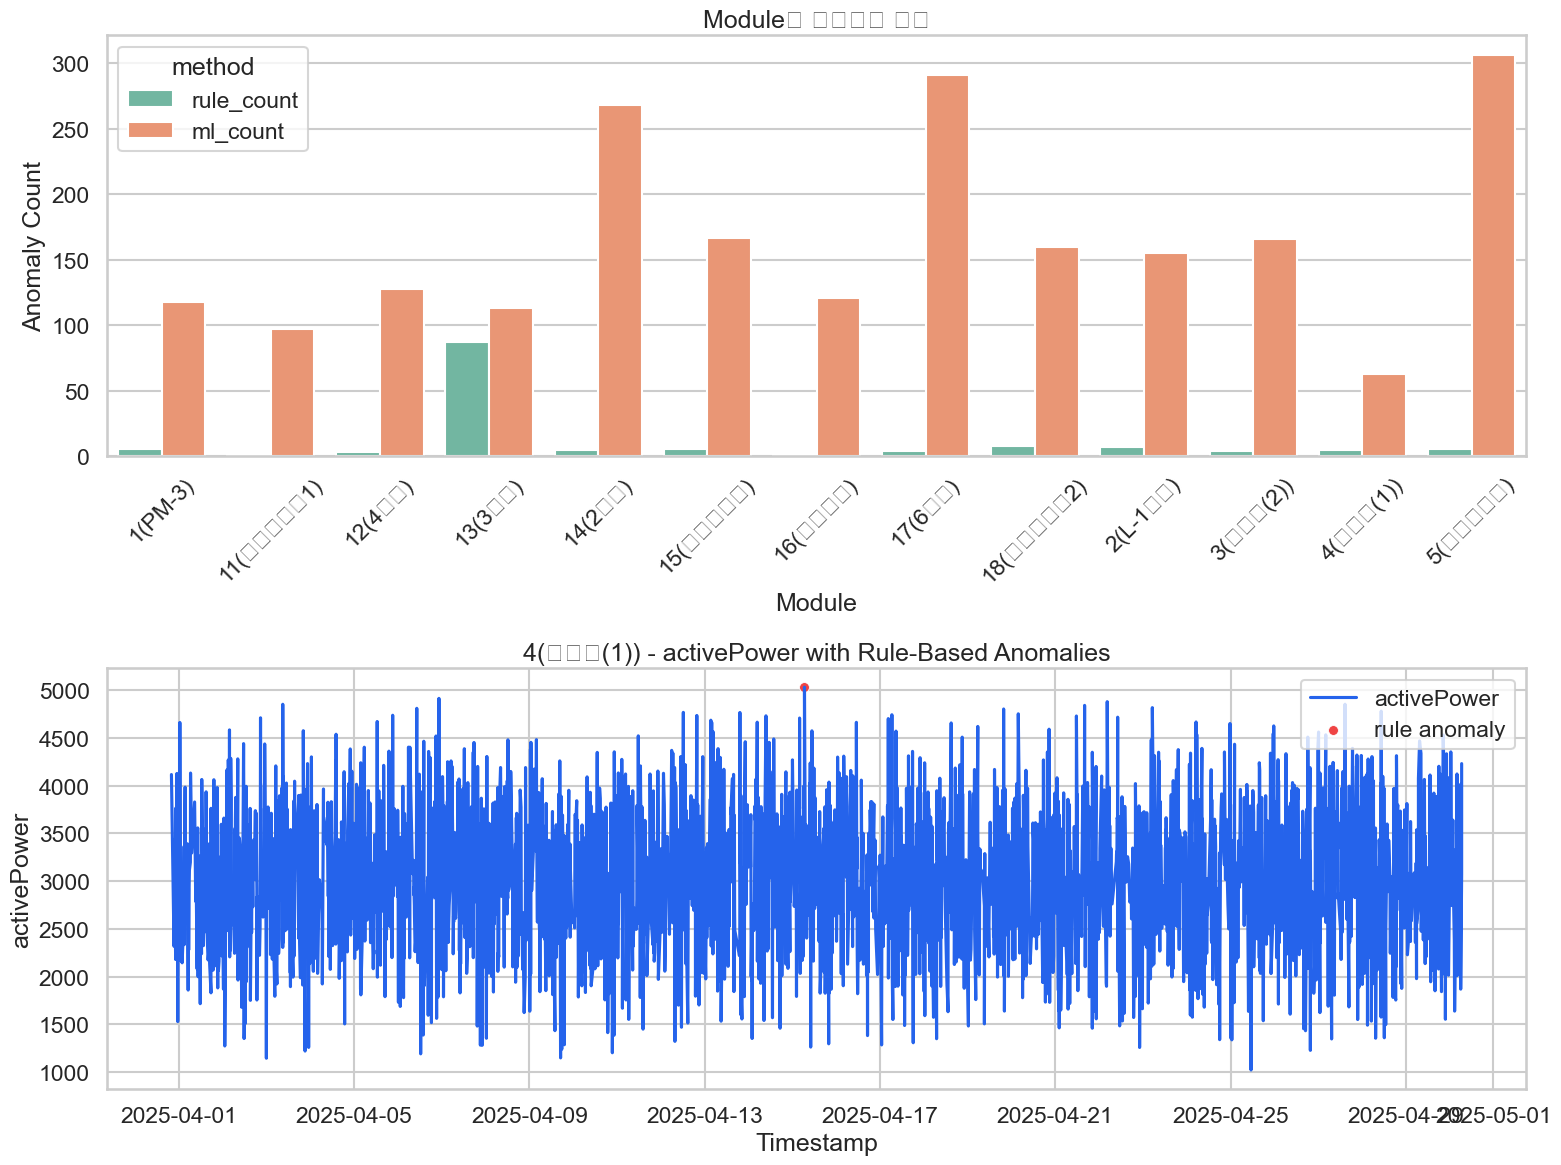

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

anomaly_plot = anomaly_summary.melt(id_vars=module_col, value_vars=["rule_count", "ml_count"], var_name="method", value_name="count")
sns.barplot(data=anomaly_plot, x=module_col, y="count", hue="method", ax=axes[0], palette="Set2")
axes[0].set_title("Module별 이상탐지 건수")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_xlabel("Module")
axes[0].set_ylabel("Anomaly Count")

plot_module = df[module_col].mode().iloc[0]
plot_base = df[df[module_col] == plot_module].copy().sort_values(time_col).tail(3000)
plot_rule = rule_anomalies[rule_anomalies[module_col] == plot_module].copy()
plot_rule = plot_rule[plot_rule[time_col].isin(plot_base[time_col])]

sns.lineplot(data=plot_base, x=time_col, y="activePower", ax=axes[1], color="#2563eb", label="activePower")
sns.scatterplot(data=plot_rule, x=time_col, y="activePower", ax=axes[1], color="#ef4444", s=50, label="rule anomaly")
axes[1].set_title(f"{plot_module} - activePower with Rule-Based Anomalies")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("activePower")

plt.tight_layout()
plt.show()

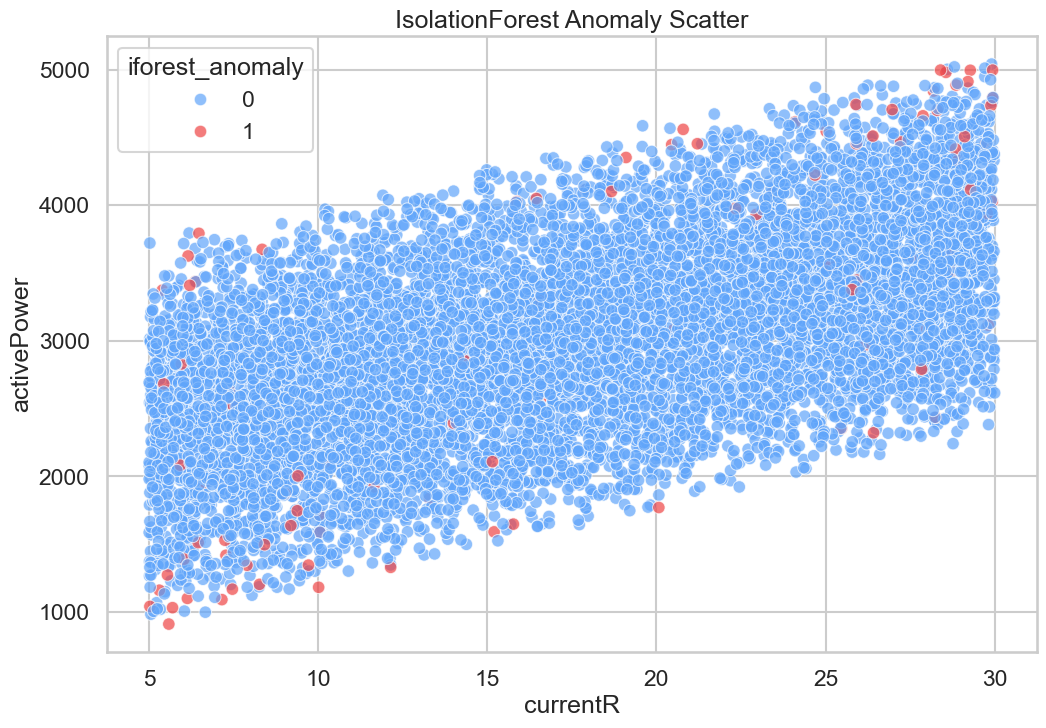

In [23]:
scatter_cols = [c for c in ["currentR", "activePower"] if c in df.columns]
if len(scatter_cols) == 2:
    scatter_base = df[[time_col, module_col] + scatter_cols].dropna().copy()
    scatter_base = scatter_base.merge(
        ml_result[[time_col, "iforest_anomaly"]].drop_duplicates(),
        on=time_col,
        how="left"
    )
    scatter_base["iforest_anomaly"] = scatter_base["iforest_anomaly"].fillna(0).astype(int)

    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=scatter_base.sample(min(len(scatter_base), 10000), random_state=42),
        x=scatter_cols[0],
        y=scatter_cols[1],
        hue="iforest_anomaly",
        palette={0: "#60a5fa", 1: "#ef4444"},
        alpha=0.7
    )
    plt.title("IsolationForest Anomaly Scatter")
    plt.show()

## 5. 결과 파일

In [24]:
print("output_dir:", output_dir)
for file in sorted(output_dir.glob("*.csv")):
    print("-", file.name)

output_dir: c:\Users\EL094\Documents\PdM_Project\ml_outputs
- daily_forecast_predictions.csv
- hourly_forecast_predictions.csv
- ml_anomalies_isolation_forest.csv
- rule_based_anomalies.csv
